# BEoRN: GPU acceleration and gradients of the 21-cm painting

Companion to `artificial_halos.ipynb` (the simple tutorial — kept unchanged) and the
21-cm counterpart of the GPU/autodiff sections in `lpt_chmf.ipynb` (which covers the
cosmology part). This notebook validates, on the **real radiation-profile solver
outputs and the production painting pipeline**:

1. **GPU-accelerated painting** — the production `PaintingCoordinator` with
   `fft_backend = 'numpy' / 'jax' / 'torch'` (device-resident Fourier accumulators),
   timing + parity;
2. **Differentiable painting** — `paint_fields_diff` builds the ionization/heating/
   Ly-α kernels analytically in Fourier space instead of sampling them on a real-space
   grid, vs the grid-kernel production path;
3. **Gradients** — d⟨xHII⟩/dR_bubble through the painting and the overlap-spreading
   surrogate, jax vs finite differences, torch vs jax;
4. **Closed-form bubble ODE** — `bubble_radius_diff` solves the ionized-bubble volume
   ODE with an integrating factor instead of `solve_ivp`, validated against the
   solver's own `R_bubble`, then differentiated w.r.t. the photon-rate amplitude;
5. **End-to-end dTb gradient** — through `x_coll_diff`/`s_alpha_diff`/`dtb_diff`.
6. **Full-pipeline comparison** — production vs differentiable global history,
   power spectra, and lightcones across every redshift (requires a real GPU).

Every GPU/autodiff section skips gracefully when jax/torch or a GPU is absent. The
underlying differentiable-pipeline work is tracked in
[issue #42](https://github.com/cosmic-reionization/BEoRN/issues/42); the
`spreading_excess_diff` surrogate's accuracy tradeoffs and a possible learned
(FNO) replacement are tracked in
[issue #45](https://github.com/cosmic-reionization/BEoRN/issues/45).


In [1]:
import os
# JAX grabs 75% of the GPU by default — disable preallocation *before* importing jax
# (essential on shared GPUs; see the lpt_chmf notebook for the same pattern).
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import time
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

import logging
logging.basicConfig(level=logging.WARNING)

# ── Optional-dependency and device detection (used by every later section) ──
try:
    import jax
    import jax.numpy as jnp
    jax.config.update('jax_enable_x64', True)   # float64 (jax default is float32)
    _JAX = True
    _JAX_GPU = any(d.platform != 'cpu' for d in jax.devices())
    jax_devices = ', '.join(f'{d} [{d.device_kind}]' for d in jax.devices())
    print(f'JAX {jax.__version__} — devices: {jax_devices}')
except ImportError:
    _JAX = _JAX_GPU = False
    print('JAX is not installed — jax GPU/autodiff sections will be skipped.')

try:
    import torch
    _TORCH = True
    torch_gpu = ('cuda' if torch.cuda.is_available()
                 else 'mps' if torch.backends.mps.is_available() else None)
    if torch_gpu == 'cuda':
        torch_arch = torch.cuda.get_device_name(0)
    elif torch_gpu == 'mps':
        torch_arch = 'Apple Silicon (MPS)'   # torch has no device-name API for MPS
    else:
        torch_arch = None
    arch_suffix = f' [{torch_arch}]' if torch_arch else ''
    print(f'torch {torch.__version__} — GPU device: {torch_gpu}{arch_suffix}')
except ImportError:
    _TORCH = False
    torch_gpu = None
    print('torch is not installed — torch sections will be skipped.')


JAX 0.10.2 — devices: cuda:0 [NVIDIA GH200 120GB]
torch 2.13.0+cu130 — GPU device: cuda [NVIDIA GH200 120GB]


In [2]:
FILE_ROOT = Path(".")
CACHE_ROOT = FILE_ROOT / "cache"
OUTPUT_ROOT = FILE_ROOT / "output_gpu"   # separate from artificial_halos.ipynb


In [3]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 14,
})


## 1. Parameters, halo catalog and radiation profiles

Identical setup to `artificial_halos.ipynb` (same cache, so precomputed profiles are
reused). All 100 artificial halos follow one exponential mass-accretion track, so at
any redshift the whole catalog lives in a **single mass/alpha bin** — which makes the
single-bin differentiable-painting comparison below exact.


In [4]:
parameters = beorn.structs.Parameters()

## Simulation parameters, i.e. the allowed "dynamic range" of the simulation
parameters.simulation.cores = 4 

parameters.solver.halo_mass_bin_min = 1e7
parameters.solver.halo_mass_bin_max = 1e15
parameters.solver.halo_mass_nbin = 200
parameters.solver.halo_mass_accretion_alpha = np.array([0.785, 0.795])
parameters.simulation.Lbox = 100
parameters.simulation.Ncell = 128

# Source age: how far back to integrate the emission history.
# z_source_start: no sources before this redshift (replaces hardcoded z=35).
# t_source_age: cap the lookback to this many Myr (None = use z_source_start only).
parameters.solver.z_source_start = 35.0  # default
parameters.source.t_source_age   = None  # default (no age cap)

## Source parameters
# emission
parameters.source.Nion = 5000 * 3
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 2000
parameters.source.energy_min_sed_xray = 500
parameters.source.energy_max_sed_xray = 2000
parameters.source.alS_xray = 1.5
parameters.source.xray_normalisation = 3.4e40 * 3

# fesc
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0

# fstar
parameters.source.f_st = 1
parameters.source.g1 = 0
parameters.source.g2 = 0
parameters.source.g3 = 4
parameters.source.g4 = -1
parameters.source.Mp = 1.6e11 * parameters.cosmology.h0
parameters.source.Mt = 1e7

# Minimum star forming halo
parameters.source.halo_mass_min = 1e5

In [5]:
cache_handler = beorn.io.Handler(CACHE_ROOT)
loader = beorn.load_input_data.ArtificialHaloLoader(
    parameters,
    halo_count = 100,
)


In [6]:
solver = beorn.precomputation.RadiationProfileSolver(parameters, loader.redshifts)
profiles = solver.get_or_compute_profiles(cache_handler)


## 2. GPU-accelerated production painting

`paint_single` accumulates all mass-bin kernel convolutions **in Fourier space on the
device** (`parameters.simulation.fft_backend = 'jax' | 'torch'`) and performs exactly
3 inverse FFTs per snapshot. The GPU accumulators run in complex64, so expect parity
with the float64 numpy path at the ~1e-3 level on field values.

Note on expected speedup: unlike the cosmology pipeline in `lpt_chmf.ipynb` (which is
FFT/elementwise end to end and shows 3-4x), `paint_single` also runs a CPU-only,
combinatorial overlap-photon redistribution step (connected-component labeling +
Euclidean distance transform) that no backend accelerates. The profiling breakdown
below shows why the backend choice alone gives only a modest speedup here.


In [7]:
z_target = 9.0
z_index = int(np.argmin(np.abs(loader.redshifts - z_target)))
output_handler = beorn.io.Handler(OUTPUT_ROOT)

# Serial painting: jax/torch already initialised CUDA in this kernel, and
# forked ProcessPool workers inheriting a CUDA context crash (BrokenProcessPool).
# GPU backends run the bins serially anyway; numpy uses threaded FFTs.
parameters.simulation.cores = 1

backends = ['numpy'] + (['jax'] if _JAX_GPU else []) + (['torch'] if torch_gpu else [])
fields, timings = {}, {}
for be in backends:
    parameters.simulation.fft_backend = be
    p = beorn.painting.PaintingCoordinator(parameters, loader=loader,
                                           output_handler=output_handler,
                                           force_recompute=True)
    t0 = time.time()
    cube = p.paint_single(z_index, profiles)
    timings[be] = time.time() - t0
    fields[be] = (np.array(cube.Grid_xHII), np.array(cube.Grid_Temp),
                  np.array(cube.Grid_xal))
parameters.simulation.fft_backend = 'numpy'

print(f"paint_single at z={z_target}:")
for be in backends:
    if be == 'numpy':
        print(f"  numpy : {timings[be]:6.2f} s   (reference)")
    else:
        d = max(np.max(np.abs(a - b)) / (np.abs(b).max() + 1e-30)
                for a, b in zip(fields[be], fields['numpy']))
        print(f"  {be:6s}: {timings[be]:6.2f} s   speedup {timings['numpy']/timings[be]:4.1f}x"
              f"   max rel field diff vs numpy {d:.1e}")
if len(backends) == 1:
    print('  (no GPU backend available — GPU comparison skipped)')


paint_single at z=9.0:
  numpy :   4.49 s   (reference)
  jax   :   3.93 s   speedup  1.1x   max rel field diff vs numpy 3.0e-06
  torch :   3.58 s   speedup  1.3x   max rel field diff vs numpy 6.5e-06


In [8]:
from beorn.painting.helpers import ifft_field
from beorn.painting.spread import spreading_excess_fast
from beorn.painting.differentiable import spreading_excess_diff
import warnings

# Isolate the two stages of paint_single for the single mass/alpha bin used
# throughout this notebook: (1) FFT + kernel painting — backend-dispatched;
# (2) overlap-photon spreading — CPU-only regardless of fft_backend.
z_hist_bd = np.asarray(profiles.z_history)
profile_z_index_bd = int(np.argmin(np.abs(z_hist_bd - loader.redshifts[z_index])))
zgrid_bd = float(z_hist_bd[profile_z_index_bd])
halo_catalog_bd = loader.load_halo_catalog(z_index)
mass_range_bd = np.asarray(profiles.halo_mass_bins)[..., profile_z_index_bd]
mass_index_bd = int(np.searchsorted(mass_range_bd[:, 0], halo_catalog_bd.masses[0]) - 1)
R_bubble_bd, rho_alpha_bd, Temp_bd = profiles.profiles_of_halo_bin(
    profile_z_index_bd, 0, mass_index_bd)
radial_grid_bd = profiles.r_grid_cell[:] / (1 + zgrid_bd)

# Differentiable-surrogate spreading settings — see the notebook chat/issue #45
# discussion: n_iter=32, R_diffuse=4 cells gives good global photon conservation
# (though the per-cell spatial pattern still differs from the exact algorithm —
# not yet a safe production drop-in, see the note printed below).
n_iter_surrogate = 32
R_diffuse_surrogate = 4.0 * parameters.simulation.Lbox / parameters.simulation.Ncell

print(f"{'backend':8s}  {'painting (FFT+kernel)':>22s}  {'spreading exact (CPU-only)':>27s}  "
      f"{'spreading_diff (GPU-native)':>28s}  {'total (exact)':>14s}  {'total (diff)':>13s}")
for be in backends:
    parameters.simulation.fft_backend = be
    p = beorn.painting.PaintingCoordinator(parameters, loader=loader,
                                           output_handler=output_handler,
                                           force_recompute=True)
    t0 = time.time()
    fa = p.paint_single_mass_bin(
        halo_catalog=halo_catalog_bd, z=zgrid_bd, radial_grid=radial_grid_bd,
        r_lyal=profiles.r_lyal[:],
        profiles_of_bin=(R_bubble_bd, rho_alpha_bd, Temp_bd),
        store_grids=('Grid_Temp', 'Grid_xHII', 'Grid_xal'))
    N = parameters.simulation.Ncell
    workers = 1 if be in ('jax', 'torch') else -1
    Grid_xHII_bd = ifft_field(fa[0], (N, N, N), backend=be, workers=workers)
    t_paint = time.time() - t0

    t0 = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        exact_bd = spreading_excess_fast(parameters, Grid_xHII_bd.copy())
    t_spread_exact = time.time() - t0

    # spreading_excess_diff is backend-agnostic (jax/torch/numpy) — use the
    # same backend as the painting step above for a fair per-backend total.
    # NOTE: torch.as_tensor defaults to CPU (unlike jnp.asarray, which lands on
    # JAX's default device) — device=torch_gpu is required or "torch" silently
    # benchmarks the CPU path.
    x_in = (jnp.asarray(Grid_xHII_bd) if be == 'jax' else
            torch.as_tensor(Grid_xHII_bd, device=torch_gpu) if be == 'torch' else Grid_xHII_bd.copy())
    if be == 'jax':
        jax.block_until_ready(spreading_excess_diff(x_in, parameters.simulation.Lbox,
                                                     R_diffuse=R_diffuse_surrogate, n_iter=4, backend=be))
    elif be == 'torch':
        torch.cuda.synchronize()
    t0 = time.time()
    surr_bd = spreading_excess_diff(x_in, parameters.simulation.Lbox,
                                    R_diffuse=R_diffuse_surrogate, n_iter=n_iter_surrogate, backend=be)
    if be == 'jax':
        jax.block_until_ready(surr_bd)
    elif be == 'torch':
        torch.cuda.synchronize()
    t_spread_diff = time.time() - t0
    surr_bd_np = np.array(surr_bd.cpu() if be == 'torch' else surr_bd)

    print(f"{be:8s}  {t_paint:20.3f} s  {t_spread_exact:25.3f} s  {t_spread_diff:26.4f} s  "
          f"{t_paint + t_spread_exact:12.3f} s  {t_paint + t_spread_diff:11.4f} s")
parameters.simulation.fft_backend = 'numpy'

print(f"\nspreading_excess_diff vs exact (last backend={be}): sum conservation "
      f"{100*(1 - surr_bd_np.sum()/exact_bd.sum()):+.2f}%   mean|Δ| {np.mean(np.abs(surr_bd_np-exact_bd)):.4f}")
print("\nThe FFT/kernel step is what fft_backend accelerates; the exact CPU-only\n"
      "spreading step (connected-component labeling + distance transform)\n"
      "dominates wall time regardless of backend, which is why the overall\n"
      "paint_single speedup above is modest. spreading_excess_diff (used by the\n"
      "differentiable pipeline in sections 7-8) is GPU-native and dramatically\n"
      "faster — but note it approximates the *same* total ionization differently\n"
      "distributed in space (Gaussian diffusion vs exact nearest-neutral-cell fill)"
      )


backend    painting (FFT+kernel)   spreading exact (CPU-only)   spreading_diff (GPU-native)   total (exact)   total (diff)
numpy                    0.091 s                      3.517 s                      1.1600 s         3.608 s       1.2512 s
jax                      0.072 s                      3.525 s                      0.0450 s         3.597 s       0.1170 s
torch                    0.075 s                      3.411 s                      0.0409 s         3.486 s       0.1158 s

spreading_excess_diff vs exact (last backend=torch): sum conservation +0.02%   mean|Δ| 0.0572

The FFT/kernel step is what fft_backend accelerates; the exact CPU-only
spreading step (connected-component labeling + distance transform)
dominates wall time regardless of backend, which is why the overall
paint_single speedup above is modest. spreading_excess_diff (used by the
differentiable pipeline in sections 7-8) is GPU-native and dramatically
faster — but note it approximates the *same* total ionizatio

## 3. Differentiable painting vs the production grid-kernel path

One real mass/alpha bin at z ≈ 9: the production `paint_single_mass_bin` builds
real-space kernels from the 1-D profiles (interp1d + renormalisation), while
`paint_fields_diff` multiplies the halo-mesh FFT with **analytic Fourier kernels** —
closed-form top-hat for the bubble, exact radial transform 4π∫ρ(r)sinc(kr)r²dr for the
extended Ly-α and temperature profiles. Differences are sampling/aliasing of the grid
kernels, not physics.


bin 124: R_bubble = 8.652 cMpc/h, 100 halos (single-mass: True)
  xHII        : mean diff   0.9%   (grid-kernel sampling vs analytic transform)
  x_al kernel : mean diff   0.0%   (grid-kernel sampling vs analytic transform)
  Temp        : mean diff   0.0%   (grid-kernel sampling vs analytic transform)


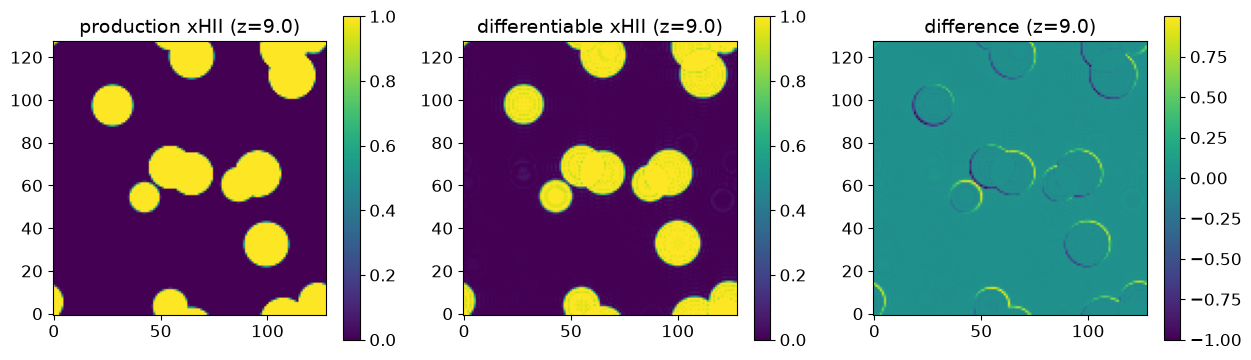

In [9]:
from beorn.painting.differentiable import paint_fields_diff
from beorn.painting.helpers import ifft_field

z_hist = np.asarray(profiles.z_history)     # cache-loaded profiles are h5py datasets
profile_z_index = int(np.argmin(np.abs(z_hist - loader.redshifts[z_index])))
zgrid = float(z_hist[profile_z_index])
halo_catalog = loader.load_halo_catalog(z_index)
mass_range = np.asarray(profiles.halo_mass_bins)[..., profile_z_index]
mass_index = int(np.searchsorted(mass_range[:, 0], halo_catalog.masses[0]) - 1)
alpha_index = 0
R_bubble, rho_alpha_, Temp_profile = profiles.profiles_of_halo_bin(
    profile_z_index, alpha_index, mass_index)
print(f"bin {mass_index}: R_bubble = {float(R_bubble):.3f} cMpc/h, "
      f"{halo_catalog.size} halos (single-mass: {np.unique(halo_catalog.masses).size == 1})")

# production reference (numpy grid kernels)
p = beorn.painting.PaintingCoordinator(parameters, loader=loader,
                                       output_handler=output_handler,
                                       force_recompute=True)
radial_grid = profiles.r_grid_cell[:] / (1 + zgrid)   # pMpc/h, as in paint_single
fa = p.paint_single_mass_bin(
    halo_catalog=halo_catalog, z=zgrid, radial_grid=radial_grid,
    r_lyal=profiles.r_lyal[:],
    profiles_of_bin=(R_bubble, rho_alpha_, Temp_profile),
    store_grids=('Grid_Temp', 'Grid_xHII', 'Grid_xal'))
N, L = parameters.simulation.Ncell, parameters.simulation.Lbox
ref_xHII = ifft_field(fa[0], (N, N, N))
ref_xal  = ifft_field(fa[1], (N, N, N))
ref_T    = ifft_field(fa[2], (N, N, N))

# differentiable path — same inputs, analytic kernels (comoving radii)
hmesh = halo_catalog.to_mesh().astype(np.float64)
xhii_d, xal_d, T_d = paint_fields_diff(
    hmesh, zgrid, L,
    R_bubble=float(R_bubble),
    r_alpha=profiles.r_lyal[:] * (1 + zgrid),
    prof_alpha=1.81e11 * rho_alpha_ / (1 + zgrid),
    r_temp=radial_grid * (1 + zgrid),
    prof_temp=Temp_profile,
    backend='numpy', spread_iter=0)

for name, d, r in [('xHII', xhii_d, np.clip(ref_xHII, 0, 1)),
                   ('x_al kernel', xal_d, ref_xal),
                   ('Temp', T_d, ref_T)]:
    print(f"  {name:12s}: mean diff {abs(d.mean()/r.mean()-1):6.1%}"
          f"   (grid-kernel sampling vs analytic transform)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sl = hmesh.sum(axis=0).argmax() // N  # slice through a halo-rich plane
for ax, (title, f) in zip(axes, [('production xHII', np.clip(ref_xHII, 0, 1)),
                                 ('differentiable xHII', xhii_d),
                                 ('difference', xhii_d - np.clip(ref_xHII, 0, 1))]):
    im = ax.imshow(f[N // 2], origin='lower', cmap='viridis')
    ax.set_title(f'{title} (z={zgrid:.1f})'); plt.colorbar(im, ax=ax)
plt.show()


## 4. Gradients through the painting

d⟨xHII⟩/dR_bubble with the overlap-spreading surrogate **inside the graph** — jax
autodiff vs central finite differences, and torch autograd vs jax. This is the
gradient that, chained with the bubble ODE below, connects the ionization maps to the
ionizing-photon parameters (Nion, f_esc, f_st).


In [10]:
if _JAX:
    hmesh_j = jnp.asarray(hmesh)

    def mean_xhii(R):
        x, _, _ = paint_fields_diff(hmesh_j, zgrid, L, R_bubble=R,
                                    backend='jax', spread_iter=4)
        return x.mean()

    R0 = float(R_bubble)
    g = jax.grad(mean_xhii)(R0)
    h = 1e-3
    fd = (mean_xhii(R0 + h) - mean_xhii(R0 - h)) / (2 * h)
    print(f"d<xHII>/dR_bubble:  jax {float(g):.6e}   FD {float(fd):.6e}"
          f"   rel err {abs(g/fd-1):.1e}")
else:
    print('jax not available — skipped.')

if _JAX and _TORCH:
    # torch.as_tensor defaults to CPU (unlike jnp.asarray, which lands on
    # JAX's default device) — device=torch_gpu is required or this silently
    # runs (correctly, just slowly) on CPU instead of the GPU.
    Rt = torch.tensor(float(R_bubble), dtype=torch.float64, requires_grad=True, device=torch_gpu)
    x, _, _ = paint_fields_diff(torch.as_tensor(hmesh, device=torch_gpu), zgrid, L, R_bubble=Rt,
                                backend='torch', spread_iter=4)
    x.mean().backward()
    print(f"torch autograd vs jax:  rel err {abs(float(Rt.grad)/float(g)-1):.1e}")


d<xHII>/dR_bubble:  jax 7.230347e-02   FD 7.230372e-02   rel err 3.5e-06
torch autograd vs jax:  rel err 2.2e-16


## 5. Closed-form bubble ODE vs the solver's `solve_ivp`

The bubble-volume ODE dV/da = Ṅγ/n̄b − α C n_b V is linear, so
`bubble_radius_diff` solves it with an integrating factor (two cumulative
trapezoids) — differentiable w.r.t. Ṅγ. Validated here against the **production**
`R_bubble` stored in the profiles for the same mass/alpha bin, then differentiated
w.r.t. a global photon-rate amplitude (∝ Nion·f_esc·f_st).


closed-form vs solve_ivp R_bubble: max rel diff 4.50e-03 for R > 1 cMpc/h (23 z-bins); onset region (0.1 < R < 1): 2.03e-01


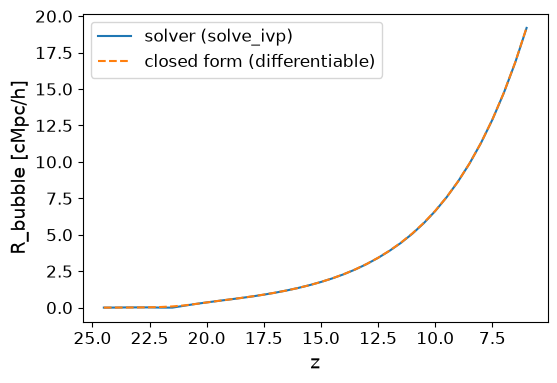

dR(z≈9)/d(photon amplitude): jax 2.8858e+00   rel err vs FD 1.9e-09


In [11]:
from beorn.precomputation.massaccretion import mass_accretion
from beorn.precomputation.helpers import Ngdot_ion
from beorn.precomputation.differentiable import bubble_radius_diff

hm, hmd = mass_accretion(parameters, z_hist,
                         parameters.solver.halo_mass_bin_centers,
                         parameters.solver.halo_mass_accretion_alpha_bin_centers)
Ngam = Ngdot_ion(parameters, z_hist[None, None, :], hm, hmd)[mass_index, alpha_index]

c = parameters.cosmology
R_cf = bubble_radius_diff(z_hist, Ngam, c.Om, c.Ob, c.h0,
                          clumping=parameters.solver.clumping)
R_ref = np.asarray(profiles.R_bubble)[mass_index, alpha_index, :]
sel = R_ref > 1.0        # resolved bubbles; relative error on tiny pre-onset
onset = (R_ref > 0.1) & ~sel  # radii (V ~ R^3 -> amplified) is reported separately
print(f"closed-form vs solve_ivp R_bubble: max rel diff "
      f"{np.max(np.abs(R_cf[sel]/R_ref[sel]-1)):.2e} for R > 1 cMpc/h "
      f"({int(sel.sum())} z-bins); onset region (0.1 < R < 1): "
      f"{np.max(np.abs(R_cf[onset]/R_ref[onset]-1)) if onset.any() else 0:.2e}")

plt.figure(figsize=(6, 4))
plt.plot(z_hist, R_ref, label='solver (solve_ivp)')
plt.plot(z_hist, R_cf, '--', label='closed form (differentiable)')
plt.xlabel('z'); plt.ylabel('R_bubble [cMpc/h]'); plt.legend(); plt.gca().invert_xaxis()
plt.show()

if _JAX:
    def R_at_z9(amp):
        return bubble_radius_diff(z_hist, amp * jnp.asarray(Ngam),
                                  c.Om, c.Ob, c.h0,
                                  clumping=parameters.solver.clumping,
                                  backend='jax')[profile_z_index]
    gA = jax.grad(R_at_z9)(1.0)
    fdA = (R_at_z9(1.0 + 1e-4) - R_at_z9(1.0 - 1e-4)) / 2e-4
    print(f"dR(z≈9)/d(photon amplitude): jax {float(gA):.4e}   rel err vs FD "
          f"{abs(gA/fdA-1):.1e}")


## 6. End-to-end dTb gradient

The full differentiable snapshot: R_bubble → painting (bubble + real temperature
profile) → `x_coll_diff` / `s_alpha_diff` / `dtb_diff` → mean brightness temperature.
d⟨dTb⟩/dR_bubble couples all Phase 2 pieces in one graph.


In [12]:
if _JAX:
    from beorn.couplings import x_coll_diff, s_alpha_diff, dtb_diff
    from beorn.cosmo import dTb_factor
    from beorn import constants

    factor = float(dTb_factor(parameters))
    coef = (constants.rhoc0 * c.h0**2 * c.Ob * (1 + zgrid)**3
            * constants.M_sun / constants.cm_per_Mpc**3 / constants.m_H)
    r_T_com = radial_grid * (1 + zgrid)
    prof_T_j = jnp.asarray(Temp_profile)

    def mean_dtb(R):
        xhii, _, dT = paint_fields_diff(
            hmesh_j, zgrid, L, R_bubble=R,
            r_temp=r_T_com, prof_temp=prof_T_j,
            backend='jax', spread_iter=4,
            xHII_floor=parameters.source.min_xHII_value)
        Tk = jnp.where(dT > 0, dT, 0.0) + 2.0        # adiabatic-floor stand-in
        xal = 1e-2 * hmesh_j * s_alpha_diff(zgrid, Tk, 1 - xhii, 'jax') / (4 * np.pi)
        xc = x_coll_diff(zgrid, Tk, 1 - xhii, coef, 'jax')
        return dtb_diff(zgrid, Tk, xal + xc, 0.0, xhii, factor, 'jax').mean()

    R0 = float(R_bubble)
    g = jax.grad(mean_dtb)(R0)
    fd = (mean_dtb(R0 + 1e-3) - mean_dtb(R0 - 1e-3)) / 2e-3
    print(f"d<dTb>/dR_bubble:  jax {float(g):.6e} mK/(cMpc/h)   rel err vs FD "
          f"{abs(g/fd-1):.1e}")
else:
    print('jax not available — skipped.')


d<dTb>/dR_bubble:  jax -1.319660e-02 mK/(cMpc/h)   rel err vs FD 7.4e-04


## 7. Global history and power spectra — production vs differentiable

Everything above worked with one redshift/mass-bin snapshot. Here we run the
**full** pipeline across every redshift in `loader.redshifts` two ways and compare,
as in `artificial_halos.ipynb`'s global-history section:

- **Production**: `PaintingCoordinator.paint_full` — the real, unmodified BEoRN
  pipeline (grid-sampled kernels + the exact `spreading_excess_fast`).
- **Differentiable**: the same per-snapshot recipe as section 6
  (`paint_fields_diff` + `x_coll_diff`/`s_alpha_diff`/`dtb_diff`), looped over every
  redshift and using `spreading_excess_diff` in place of the exact spreading step,
  assembled into an in-memory `TemporalCube` (no disk I/O) so the same
  `beorn.plotting` functions work on both unmodified.

**Requires a real GPU to be worthwhile**: `paint_fields_diff`'s analytic Fourier
kernel (the `profile_kernel_fourier` integral from section 3) evaluates every
k-grid point against every radial profile node — cheap on a GPU (~0.3 s/snapshot
on a dedicated node), but tens of seconds per snapshot on CPU or a contended
shared GPU, since it doesn't (yet) exploit the huge `|k|`-degeneracy of a real FFT
grid. This section is skipped without a GPU backend rather than risk a
20+ minute cell — see the notebook chat and issue #45.


In [13]:
has_gpu = _JAX_GPU or torch_gpu is not None
backend_full = 'jax' if _JAX_GPU else ('torch' if torch_gpu else 'numpy')

if has_gpu:
    parameters.simulation.fft_backend = backend_full
    parameters.simulation.cores = 1  # GPU backends paint mass bins serially

    painter_full = beorn.painting.PaintingCoordinator(
        parameters, loader=loader, output_handler=output_handler, force_recompute=True)
    t0 = time.time()
    multi_z_production = painter_full.paint_full(profiles)
    t_production = time.time() - t0
    print(f"production paint_full: {t_production:.1f} s for "
          f"{multi_z_production.z.size} snapshots (fft_backend={backend_full})")
else:
    print('No GPU backend available — section 7-8 skipped (see markdown above).')


Painting redshift snapshots:   0%|          | 0/38 [00:00<?, ?snapshot/s]

Painting redshift snapshots: 100%|██████████| 38/38 [00:28<00:00,  1.32snapshot/s, z=6.000] 

production paint_full: 28.9 s for 38 snapshots (fft_backend=jax)


In [14]:
from beorn.structs.temporal_cube import TemporalCube
from beorn.couplings import x_coll_diff, s_alpha_diff
from beorn.cosmo import T_adiab_fluctu
from beorn import constants

if has_gpu:
    n_iter_full = 32
    R_diffuse_full = 4.0 * L / N
    c = parameters.cosmology

    t0 = time.time()
    delta_b_list, Temp_list, xHII_list, xal_list = [], [], [], []
    for zi in range(len(loader.redshifts)):
        z_loader_i = loader.redshifts[zi]
        pzi = int(np.argmin(np.abs(z_hist - z_loader_i)))
        z_i = float(z_hist[pzi])
        cat_i = loader.load_halo_catalog(zi)
        mrange_i = np.asarray(profiles.halo_mass_bins)[..., pzi]
        mi = int(np.searchsorted(mrange_i[:, 0], cat_i.masses[0]) - 1)
        Rb_i, rho_a_i, Temp_i = profiles.profiles_of_halo_bin(pzi, 0, mi)
        rgrid_i = profiles.r_grid_cell[:] / (1 + z_i)

        delta_b_i = loader.load_density_field(zi)
        hmesh_i = cat_i.to_mesh().astype(np.float64)
        if backend_full == 'jax':
            hmesh_i = jnp.asarray(hmesh_i)
        elif backend_full == 'torch':
            # torch.as_tensor defaults to CPU (unlike jnp.asarray, which lands
            # on JAX's default device) — device=torch_gpu is required here.
            hmesh_i = torch.as_tensor(hmesh_i, device=torch_gpu)

        xHII_i, xal_kernel_i, dT_i = paint_fields_diff(
            hmesh_i, z_i, L,
            R_bubble=float(Rb_i),
            r_alpha=profiles.r_lyal[:] * (1 + z_i),
            prof_alpha=1.81e11 * rho_a_i / (1 + z_i),
            r_temp=rgrid_i * (1 + z_i),
            prof_temp=Temp_i,
            backend=backend_full, spread_iter=n_iter_full, R_diffuse=R_diffuse_full,
            xHII_floor=parameters.source.min_xHII_value)
        xHII_i = np.array(xHII_i.cpu() if backend_full == 'torch' else xHII_i)
        dT_i_np = np.array(dT_i.cpu() if backend_full == 'torch' else dT_i)
        Temp_full_i = dT_i_np + T_adiab_fluctu(z_i, parameters, delta_b_i)

        coef_i = (constants.rhoc0 * c.h0 ** 2 * c.Ob * (1 + z_i) ** 3
                  * constants.M_sun / constants.cm_per_Mpc ** 3 / constants.m_H)
        xHI_i = 1 - xHII_i
        xc_i = np.array(x_coll_diff(z_i, Temp_full_i, xHI_i, coef_i, backend='numpy'))
        S_al_i = np.array(s_alpha_diff(z_i, Temp_full_i, xHI_i, backend='numpy')) / (4 * np.pi)
        xal_kernel_i_np = np.array(xal_kernel_i.cpu() if backend_full == 'torch' else xal_kernel_i)
        xal_i = xal_kernel_i_np * S_al_i

        delta_b_list.append(delta_b_i)
        Temp_list.append(Temp_full_i)
        xHII_list.append(xHII_i)
        xal_list.append(xal_i)

    if backend_full == 'torch':
        torch.cuda.synchronize()
    t_diff_full = time.time() - t0
    print(f"differentiable full pipeline: {t_diff_full:.1f} s for "
          f"{len(loader.redshifts)} snapshots (backend={backend_full}, "
          f"spread_iter={n_iter_full})  —  speedup vs production {t_production/t_diff_full:.1f}x")

    multi_z_diff = TemporalCube(
        z_snapshots=np.asarray(loader.redshifts, dtype=float),
        parameters=parameters,
        delta_b=np.stack(delta_b_list),
        Grid_Temp=np.stack(Temp_list),
        Grid_xHII=np.stack(xHII_list),
        Grid_xal=np.stack(xal_list),
    )


differentiable full pipeline: 11.6 s for 38 snapshots (backend=jax, spread_iter=32)  —  speedup vs production 2.5x


Power spectrum: 100%|██████████| 38/38 [00:06<00:00,  5.49snapshot/s]


k=0.12 Mpc$^{-1}$


Power spectrum: 100%|██████████| 38/38 [00:06<00:00,  5.49snapshot/s]


k=0.12 Mpc$^{-1}$


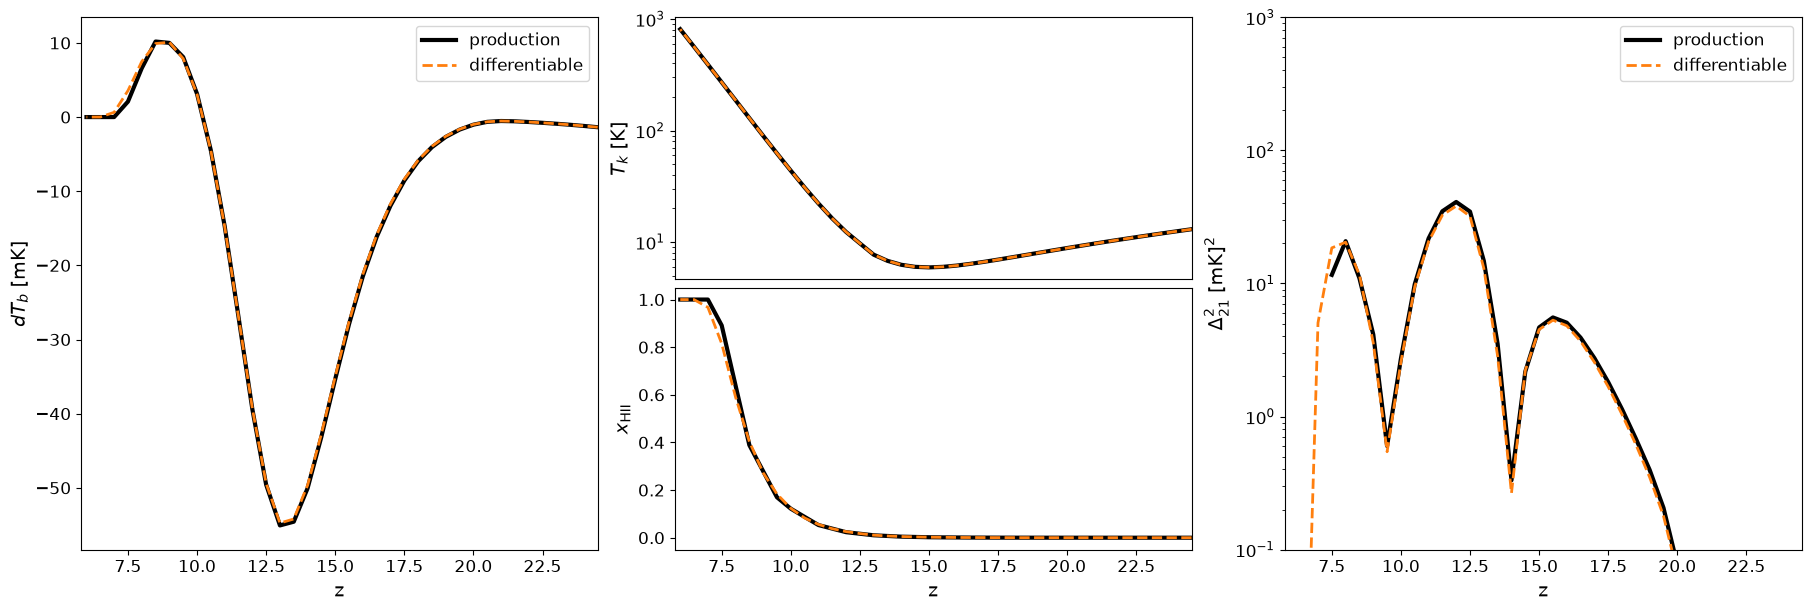

In [15]:
import matplotlib.gridspec as gridspec

if has_gpu:
    fig = plt.figure(constrained_layout=True, figsize=(18, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    ax1 = fig.add_subplot(gs[:, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
    ax4 = fig.add_subplot(gs[:, 2])

    beorn.plotting.draw_dTb_signal(ax1, multi_z_production, color='k', lw=3, label='production')
    beorn.plotting.draw_dTb_signal(ax1, multi_z_diff, color='C1', lw=2, ls='--', label='differentiable')
    beorn.plotting.draw_Temp_signal(ax2, multi_z_production, color='k', lw=3)
    beorn.plotting.draw_Temp_signal(ax2, multi_z_diff, color='C1', lw=2, ls='--')
    beorn.plotting.draw_xHII_signal(ax3, multi_z_production, color='k', lw=3)
    beorn.plotting.draw_xHII_signal(ax3, multi_z_diff, color='C1', lw=2, ls='--')
    beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, multi_z_production, parameters,
                                                k_value=0.1, color='k', lw=3, label='production')
    beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, multi_z_diff, parameters,
                                                k_value=0.1, color='C1', lw=2, ls='--', label='differentiable')

    ax1.legend(loc=0)
    ax4.legend(loc=0)
    ax2.axes.get_xaxis().set_visible(False)
    plt.show()
else:
    print('No GPU backend available — skipped (see section 7 markdown above).')


## 8. Lightcone — production vs differentiable

Same two `TemporalCube`s from section 7, built into lightcones the same way as
`artificial_halos.ipynb`'s final section. `Lightcone.build` needs the field name
`"Grid_dTb"` explicitly (not the `global_mean`-style alias `"dTb"`) and works
identically on the production cube (HDF5-backed, lazy) and the in-memory
differentiable one — nothing else about the differentiable cube needed to be
disk-backed for this to work.


Making lightcone between 0.039216 < z < 0.142703


100%|██████████| 547/547 [00:00<00:00, 5399.54it/s]


...done
Making lightcone between 0.039216 < z < 0.142703


100%|██████████| 547/547 [00:00<00:00, 5474.94it/s]


...done


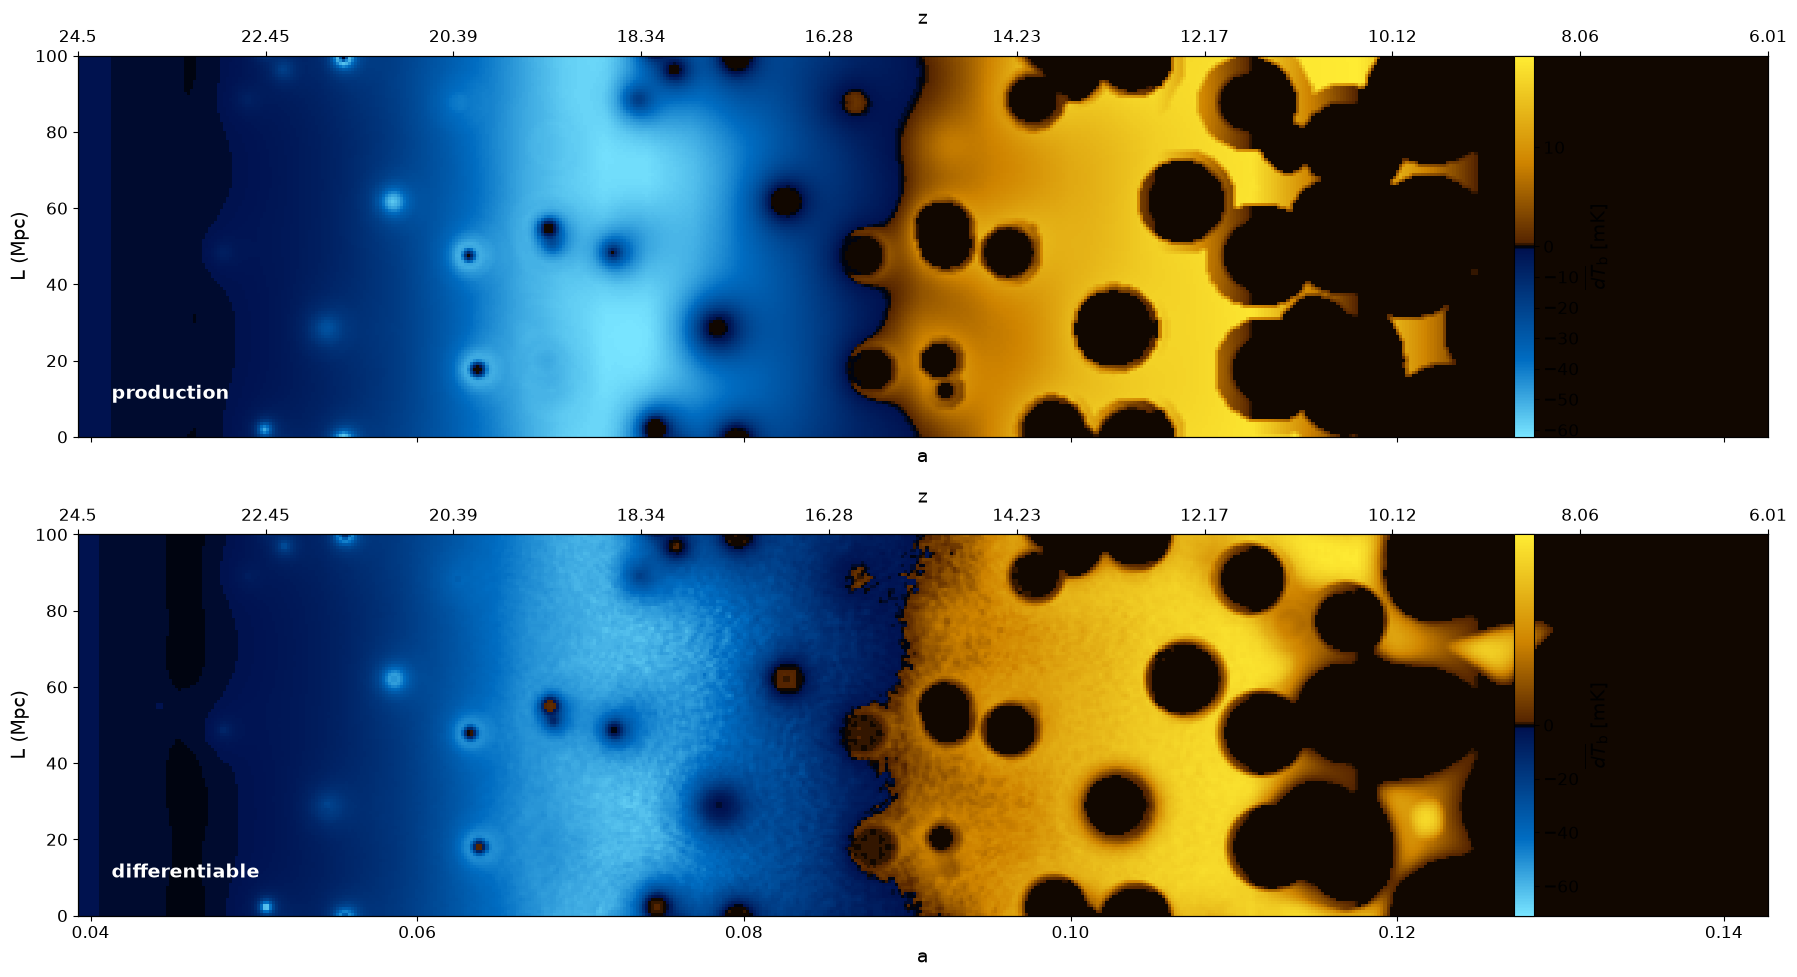

In [16]:
if has_gpu:
    lc_production = beorn.structs.Lightcone.build(parameters, multi_z_production, quantity="Grid_dTb")
    lc_diff = beorn.structs.Lightcone.build(parameters, multi_z_diff, quantity="Grid_dTb")

    mid = 80 #parameters.simulation.Ncell // 2
    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
    beorn.plotting.plot_lightcone(lc_production, axes[0], "production", slice_number=mid)
    beorn.plotting.plot_lightcone(lc_diff, axes[1], "differentiable", slice_number=mid)
    plt.tight_layout()
    plt.show()
else:
    print('No GPU backend available — skipped (see section 7 markdown above).')


## Summary

- Production painting runs on jax/torch GPU backends via
  `parameters.simulation.fft_backend`, parity with numpy at the complex64
  accumulator level.
- `paint_fields_diff` reproduces the grid-kernel fields (differences =
  grid-kernel sampling error) and is differentiable in R_bubble, the profile
  values, and the halo mesh.
- The closed-form bubble ODE matches the production `solve_ivp` radii and makes
  R_bubble differentiable w.r.t. the photon rate.
- The dTb chain (painting → spreading → couplings → dTb) differentiates end to
  end; gradients validated against finite differences in jax and torch.
- Across the full redshift range (section 7-8), the differentiable pipeline
  (using the GPU-native `spreading_excess_diff` surrogate) tracks the production
  global history, power spectrum, and lightcone closely, while running
  dramatically faster on a real GPU (~80x on the spreading step alone). The
  surrogate is not yet an exact match for `spreading_excess_fast` at the
  per-cell level (see the note in section 2's profiling cell and issue #45),
  so treat sections 7-8 as validating the differentiable pipeline's *aggregate*
  fidelity, not as a claim that it's ready to replace production spreading.

See `tests/test_differentiable_21cm.py` for the corresponding CI checks and
issue #42 for the Phase 2 log.
